In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
warnings.filterwarnings('ignore')

In [2]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')

In [3]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [4]:
sber_5 = good_dataframe(sber, '5 min')
sber_5.head()

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,SBRF,5 min,2301.0,2346.0,2265.0,2334.0,769
1,2009-01-11 10:35:00,SBRF,5 min,2334.0,2338.0,2320.0,2327.0,399
2,2009-01-11 10:40:00,SBRF,5 min,2322.0,2341.0,2322.0,2340.0,1825
3,2009-01-11 10:45:00,SBRF,5 min,2341.0,2355.0,2340.0,2350.0,2444
4,2009-01-11 10:50:00,SBRF,5 min,2350.0,2376.0,2349.0,2370.0,1614


In [5]:
# Преобразуем датафрейм для удобства работы с 2 свечными паттернами
def shift_features_2_candle(data):
    """Смещает все основные столбцы на 1 период назад

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['time', 'ticker', 'per', 'open', 'high', 'low', 'close', 'volume']

    Returns:
        data (pd.DataFrame): Новый DataFrame с преобразованными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']
    """
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

sber_5s = shift_features_2_candle(sber_5)
sber_5s.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00


In [6]:
# Размечаем датафрейм паттерном бычье поглощение
def detection_bullish_engulfing_pattern(data):
    """Функция для детекции бычьего паттерна поглощения

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_engulfing_pattern'
        
    """

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

sber_good = detection_bullish_engulfing_pattern(sber_5s)

In [7]:
sber_good.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00,1,0,bullish_engulfing_pattern
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00,0,1,bullish_engulfing_pattern


In [8]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    current_distance = 0
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data

In [9]:
# Функция для получения результатов стратегии
def trade_statistics_bull(data, commission=0.001):
    """Функция для проверки эффективности стратегии, состоящих из 2 свечей.
    на выходе мы получаем новый датафрейм, в котором есть все необходимые данные для анализа 
    прибыльности стратегии

    Args:
        data (pd.DataFrame): Исходный датафрейм
        commission (float, optional): Размер комиссии. Defaults to 0.001.
        
    Returns:
        data (pd.DataFrame): Новый датафрейм со всеми основными финансовыми показателями стратегии.
    """
    
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        exit_candidate = data_h['open_N'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open_N'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        profit_percent = np.round((exit_price.values - entry_price.values) / entry_price.values, 5) # % доход за сделку
        profit = exit_price - entry_price # Доход за сделку в абсолютном масштабе
        
        # Считаем прибыль стратегии купи и держи:
        capital = 100_000
        first_buy = data.loc[1, 'close_N']
        last_sell = data.loc[len(data) - 51, 'close_N']
        BH_strategy_percent = ((last_sell - first_buy) / first_buy) * 100 # В % от первоначальной суммы
        BH_strategy_capital = capital * (1 + BH_strategy_percent / 100)
        
        def calculate_relative_drawdown(lst):
            """Функция для расчета максимальной просадки в абсолютном масштабе"""
            running_max = np.maximum.accumulate(lst)
            drawdown = (running_max - lst) 
            return np.max(drawdown)
        
        # Чистая прибыль
        # Чистая прибыль с учетом комиссии в 0.1 % от абсолютных значений дохода
        absolut_profit_net = np.round(np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission)), 3)
        # Чистая прибыль с учетом комиссии в 0.1 % от % значений дохода
        percent_profit_net = np.round(np.where(profit_percent >= 0, profit_percent * (1 - commission), profit_percent * (1 + commission)), 3)
        # Общая доходность в % 
        total_return_net = np.round((np.prod(1 + percent_profit_net) - 1) * 100, 3) # общая прибыль в %
        capital_curve = np.round(capital * np.cumprod(1 + percent_profit_net), 2)
        
        
        # Статистика
        # Названия
        strategy_name = data['strategy'][1]
        per = data['per'][1]
        ticker = data['ticker'][1]
        
        # Считаем R^2 линейной регрессии, построенной по графику дохода
        X = np.array(list(range(len(capital_curve)))).reshape(-1, 1)
        y = np.array(capital_curve)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        r2 = metrics.r2_score(y, y_pred)
        
        # Заполняем итоговый список словарями со всей статистикой
        all_strategy.append({'strategy' : strategy_name,
                           'ticker' : ticker,
                           'period' : per,
                           'N' : N,
                           'trades' : len(absolut_profit_net), # Количество сделок
                           'win_rate' : np.round(np.mean(percent_profit_net > 0), 2), # Считаем по % доходу после уплаты комиссии
                           'profit_factor(%)' : np.round(np.sum(percent_profit_net[percent_profit_net > 0]) / np.abs(np.sum(percent_profit_net[percent_profit_net < 0])), 3),
                           'total_return (%)' : np.round(total_return_net, 2), 'final_capital_strategy' : capital_curve[-1],
                           'capital_curve' : capital_curve, 'profit(absolut)' : np.round(np.array(absolut_profit_net), 4),
                           'profit(%)' : np.round(np.array(percent_profit_net), 4),
                           'max_drawdown' : calculate_relative_drawdown(capital_curve), 'r2' : np.round(r2, 2),
                           'strategy_buy_and_hold (%)' : np.round(BH_strategy_percent, 1),
                           'strategy_buy_and_hold (capital)' : BH_strategy_capital})
    return pd.DataFrame(all_strategy)

result = trade_statistics_bull(sber_good)
result.head(3)

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return (%),final_capital_strategy,capital_curve,profit(absolut),profit(%),max_drawdown,r2,strategy_buy_and_hold (%),strategy_buy_and_hold (capital)
0,bullish_engulfing_pattern,SBRF,5 min,1,19601,0.28,1.016,12.52,112518.73,"[100400.0, 100199.2, 100199.2, 99998.8, 99898....","[8.991, -4.004, 0.0, -4.004, -2.002, 1.998, 3....","[0.004, -0.002, 0.0, -0.002, -0.001, 0.001, 0....",23867.42,0.22,1182.9,1.282939e+06
1,bullish_engulfing_pattern,SBRF,5 min,2,19601,0.32,0.982,-28.81,71190.15,"[101300.0, 100894.8, 100793.91, 100894.7, 1005...","[29.97, -9.009, -3.003, 2.997, -7.007, 1.998, ...","[0.013, -0.004, -0.001, 0.001, -0.003, 0.001, ...",33578.36,0.01,1182.9,1.282939e+06
2,bullish_engulfing_pattern,SBRF,5 min,3,19023,0.35,0.972,-45.93,54072.47,"[101100.0, 100594.5, 100192.12, 100292.31, 997...","[24.975, -11.011, -9.009, 2.997, -11.011, 5.99...","[0.011, -0.005, -0.004, 0.001, -0.005, 0.003, ...",56179.22,0.37,1182.9,1.282939e+06


In [10]:
def backtest_strategies_multi_tf(data):
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    data = data.copy()
    l = []
    # Перебираем все тф
    for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
        data_tm = good_dataframe(data, i)
        l.append(data_tm)
    
    all_strategy = []
    # Для каждого тф проверяем стратегию бычье поглощение
    for j in l:
        detection_data = detection_bullish_engulfing_pattern(shift_features_2_candle(j))
        final_result = trade_statistics_bull(detection_data)
        all_strategy.append(final_result)
    # Объединяем результат   
    combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf(sber)
sber_result_strategies.head(3)

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return (%),final_capital_strategy,capital_curve,profit(absolut),profit(%),max_drawdown,r2,strategy_buy_and_hold (%),strategy_buy_and_hold (capital)
0,bullish_engulfing_pattern,SBRF,5 min,1,19601,0.28,1.016,12.52,112518.73,"[100400.0, 100199.2, 100199.2, 99998.8, 99898....","[8.991, -4.004, 0.0, -4.004, -2.002, 1.998, 3....","[0.004, -0.002, 0.0, -0.002, -0.001, 0.001, 0....",23867.42,0.22,1182.9,1.282939e+06
1,bullish_engulfing_pattern,SBRF,5 min,2,19601,0.32,0.982,-28.81,71190.15,"[101300.0, 100894.8, 100793.91, 100894.7, 1005...","[29.97, -9.009, -3.003, 2.997, -7.007, 1.998, ...","[0.013, -0.004, -0.001, 0.001, -0.003, 0.001, ...",33578.36,0.01,1182.9,1.282939e+06
2,bullish_engulfing_pattern,SBRF,5 min,3,19023,0.35,0.972,-45.93,54072.47,"[101100.0, 100594.5, 100192.12, 100292.31, 997...","[24.975, -11.011, -9.009, 2.997, -11.011, 5.99...","[0.011, -0.005, -0.004, 0.001, -0.005, 0.003, ...",56179.22,0.37,1182.9,1.282939e+06


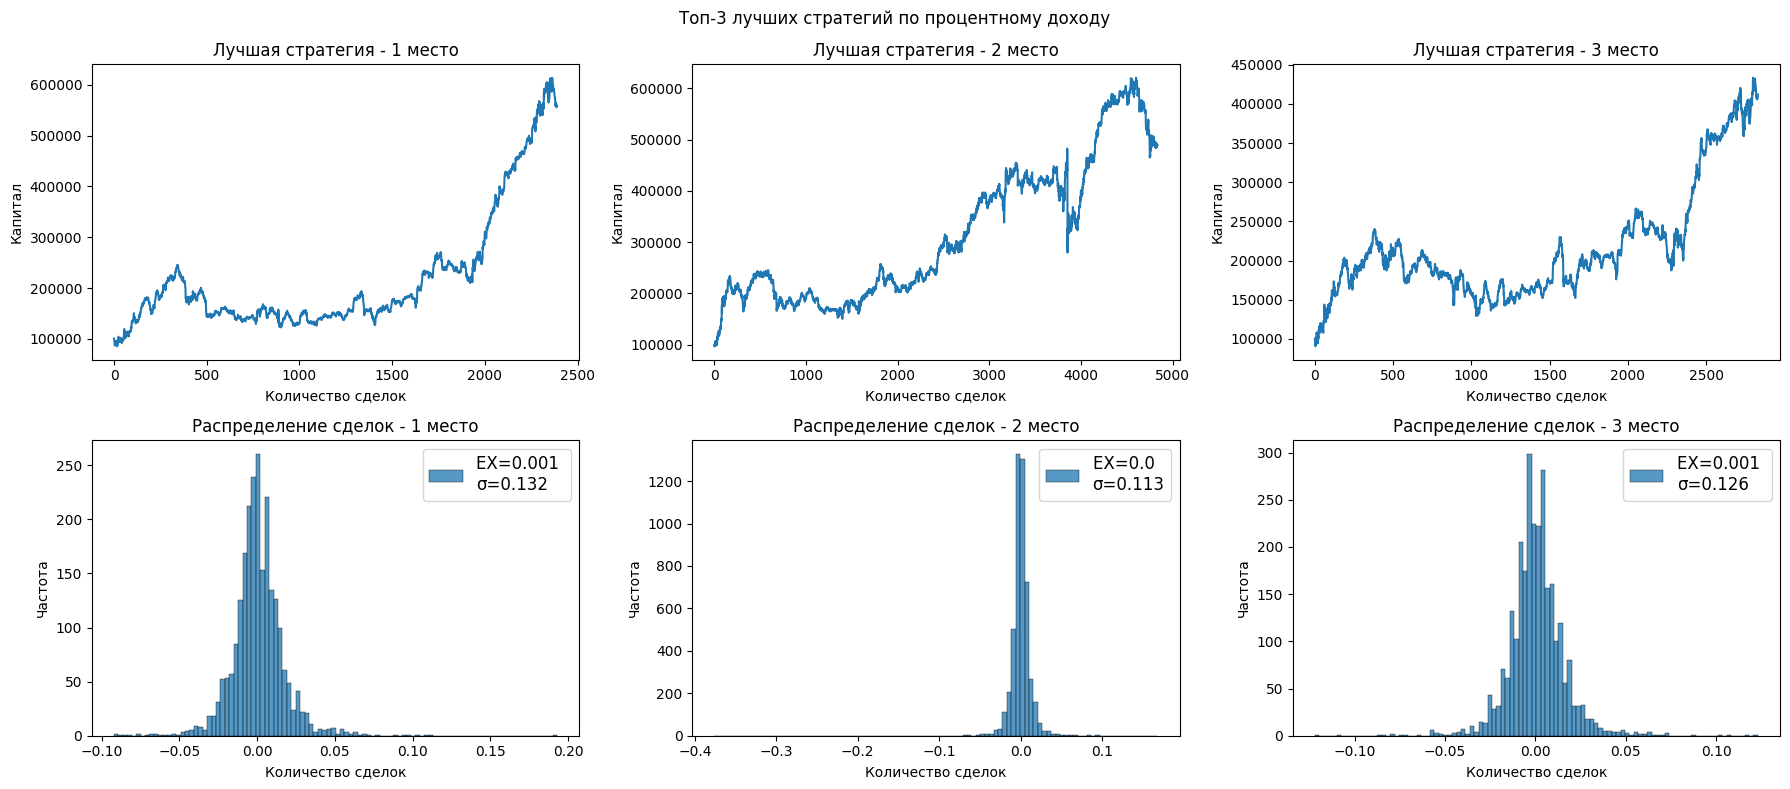

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return (%),final_capital_strategy,max_drawdown,r2,strategy_buy_and_hold (%),strategy_buy_and_hold (capital)
0,bullish_engulfing_pattern,SBRF,15 min,35,2390,0.50,1.161,458.60,558601.31,123068.13,0.52,1162.6,1.262558e+06
1,bullish_engulfing_pattern,SBRF,15 min,15,4833,0.47,1.119,389.55,489547.41,202767.28,0.83,1162.6,1.262558e+06
2,bullish_engulfing_pattern,SBRF,15 min,30,2831,0.49,1.124,311.81,411814.03,111021.70,0.53,1162.6,1.262558e+06


In [11]:
def compare_strategies(data, criterion='all'):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
        criterion (str, optional).
        Возможные значения:
        - all. Модели ранжируются по всем критериям - PF, R2, total_return (%), max drawdown
        - Profit Factor. Модели ранжируются только по 1 критерию - Profit Factor
        - R2. Модели ранжируются только по 1 критерию - R2
        - total_return (%). Модели ранжируются только по 1 критерию - total_return (%)
        - max drawdown. Модели ранжируются только по 1 критерию - max drawdown

    Returns:
        data (pd.DaraFrame): Возвращаем датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[data['trades'] > 1000] # Ограничение по количеству сделок
    data['profit_factor_rank'] = data['profit_factor(%)'].rank() # Больше лучше
    data['r2_rank'] = data['r2'].rank() # Больше лучше
    data['total_return (%) rank'] = data['total_return (%)'].rank() # Больше лучше
    data['max_drawdown_rank'] = data['max_drawdown'].rank(ascending=False) # Меньше лучше
    data['best_model'] = data['profit_factor_rank'] + data['max_drawdown_rank'] + data['r2_rank'] + data['max_drawdown_rank']
    
    # Построение графиков 3 лучших стратегий
    if criterion == 'all':
        data.sort_values('best_model', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_xlabel('Количество сделок')
        axes[0, 1].set_xlabel('Количество сделок')
        axes[0, 2].set_xlabel('Количество сделок')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_xlabel('Количество сделок')
        axes[1, 1].set_xlabel('Количество сделок')
        axes[1, 2].set_xlabel('Количество сделок')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
                
    elif criterion == 'Profit Factor':
        data.sort_values('profit_factor_rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по Profit Factor')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_xlabel('Количество сделок')
        axes[0, 1].set_xlabel('Количество сделок')
        axes[0, 2].set_xlabel('Количество сделок')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}')
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}')
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}')
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_xlabel('Количество сделок')
        axes[1, 1].set_xlabel('Количество сделок')
        axes[1, 2].set_xlabel('Количество сделок')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
        
    elif criterion == 'R2':
        data.sort_values('r2_rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по R2')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_xlabel('Количество сделок')
        axes[0, 1].set_xlabel('Количество сделок')
        axes[0, 2].set_xlabel('Количество сделок')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_xlabel('Количество сделок')
        axes[1, 1].set_xlabel('Количество сделок')
        axes[1, 2].set_xlabel('Количество сделок')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
    
    elif criterion == 'total_return (%)':
        data.sort_values('total_return (%) rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по процентному доходу')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_xlabel('Количество сделок')
        axes[0, 1].set_xlabel('Количество сделок')
        axes[0, 2].set_xlabel('Количество сделок')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_xlabel('Количество сделок')
        axes[1, 1].set_xlabel('Количество сделок')
        axes[1, 2].set_xlabel('Количество сделок')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
        
    elif criterion == 'max drawdown':
        data.sort_values('max_drawdown_rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по наименьшей просадке')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_xlabel('Количество сделок')
        axes[0, 1].set_xlabel('Количество сделок')
        axes[0, 2].set_xlabel('Количество сделок')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_xlabel('Количество сделок')
        axes[1, 1].set_xlabel('Количество сделок')
        axes[1, 2].set_xlabel('Количество сделок')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
        
    
    return data
    
res = compare_strategies(sber_result_strategies, 'total_return (%)')

In [12]:
res

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return (%),final_capital_strategy,capital_curve,...,profit(%),max_drawdown,r2,strategy_buy_and_hold (%),strategy_buy_and_hold (capital),profit_factor_rank,r2_rank,total_return (%) rank,max_drawdown_rank,best_model
0,bullish_engulfing_pattern,SBRF,15 min,35,2390,0.50,1.161,458.60,558601.31,"[100500.0, 99294.0, 94031.42, 92056.76, 87085....",...,"[0.005, -0.012, -0.053, -0.021, -0.054, 0.018,...",123068.13,0.52,1162.6,1.262558e+06,63.0,49.0,66.0,16.0,144.0
1,bullish_engulfing_pattern,SBRF,15 min,15,4833,0.47,1.119,389.55,489547.41,"[99700.0, 98304.2, 97026.25, 98578.67, 97099.9...",...,"[-0.003, -0.014, -0.013, 0.016, -0.015, 0.012,...",202767.28,0.83,1162.6,1.262558e+06,53.5,65.0,65.0,3.0,124.5
2,bullish_engulfing_pattern,SBRF,15 min,30,2831,0.49,1.124,311.81,411814.03,"[100600.0, 99392.8, 97703.12, 95944.47, 90667....",...,"[0.006, -0.012, -0.017, -0.018, -0.055, 0.034,...",111021.70,0.53,1162.6,1.262558e+06,58.0,50.5,64.0,19.0,146.5
3,bullish_engulfing_pattern,SBRF,1h,9,1632,0.51,1.188,302.51,402508.62,"[101000.0, 101505.0, 103839.62, 110381.51, 110...",...,"[0.01, 0.005, 0.023, 0.063, -0.003, 0.014, 0.0...",104490.38,0.29,1167.3,1.267349e+06,66.0,33.0,63.0,23.0,145.0
4,bullish_engulfing_pattern,SBRF,15 min,45,1679,0.50,1.157,275.44,375438.26,"[100400.0, 93773.6, 89366.24, 85076.66, 83545....",...,"[0.004, -0.066, -0.047, -0.048, -0.018, 0.032,...",98096.43,0.65,1162.6,1.262558e+06,62.0,56.0,62.0,28.0,174.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,bullish_engulfing_pattern,SBRF,5 min,35,6983,0.46,0.997,-35.74,64256.58,"[100000.0, 99700.0, 99101.8, 99101.8, 99002.7,...",...,"[0.0, -0.003, -0.006, -0.0, -0.001, 0.017, -0....",163783.29,0.63,1182.9,1.282939e+06,11.0,55.0,5.0,8.0,82.0
62,bullish_engulfing_pattern,SBRF,5 min,4,18458,0.37,0.982,-38.51,61493.85,"[100900.0, 100698.2, 100396.11, 100496.5, 9989...",...,"[0.009, -0.002, -0.003, 0.001, -0.006, 0.002, ...",47126.40,0.02,1182.9,1.282939e+06,6.5,7.0,4.0,58.0,129.5
63,bullish_engulfing_pattern,SBRF,5 min,3,19023,0.35,0.972,-45.93,54072.47,"[101100.0, 100594.5, 100192.12, 100292.31, 997...",...,"[0.011, -0.005, -0.004, 0.001, -0.005, 0.003, ...",56179.22,0.37,1182.9,1.282939e+06,5.0,39.0,3.0,55.0,154.0
64,bullish_engulfing_pattern,SBRF,5 min,6,17284,0.39,0.970,-56.54,43454.85,"[100800.0, 100598.4, 100598.4, 100900.2, 10039...",...,"[0.008, -0.002, 0.0, 0.003, -0.005, 0.0, 0.0, ...",68902.26,0.69,1182.9,1.282939e+06,4.0,59.5,2.0,45.0,153.5
